In [1]:
import pandas as pd
import numpy
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# from sklearn.cluster import AgglomerativeClustering
# from sklearn.manifold import TSNE

warnings.filterwarnings(action = 'ignore')

# Data Preprocessing
Using the RFM analysis done in another notebook, is it be possible to group, or cluster, customers together based upon the `Quantity` of items purchased or `TotalPrice` spent?

In [2]:
# Import data
data = pd.read_excel('./Data/Online Retail_Analysis.xlsx',
                     header = 0,
                     sheet_name = 'RFM')

In [3]:
data.head()

,CustomerID,Country,NumInvoices,LastInvoiceDate,day_since_last_purchase,AvgDaysBetweenPurchases,TotalSpend,AvgSpend
0,12346.0,United Kingdom,1,2011-01-18 10:01:00,347,NaN,77183.60,77183.600000
1,12347.0,Iceland,7,2011-12-07 15:52:00,24,60.333333,4310.00,615.714286
2,12348.0,Finland,4,2011-09-25 13:13:00,97,94.000000,1797.24,449.310000
3,12349.0,Italy,1,2011-11-21 09:51:00,40,NaN,1757.55,1757.550000
4,12350.0,Norway,1,2011-02-02 16:01:00,332,NaN,334.40,334.400000


In [4]:
data_features = data[['TotalSpend',
                      'day_since_last_purchase',
                      'AvgDaysBetweenPurchases']]\
                .dropna()

In [5]:
scaler = StandardScaler()

In [6]:
data_scaled = pd.DataFrame(scaler.fit_transform(data_features),
                          columns = data_features.columns)

# K-Means Clustering

In [7]:
# Set random seed
random_seed_num = 2026
np.random.seed(random_seed_num)

<IPython.core.display.Javascript object>

## Parameter Tuning: Elbow Method

When trying the find the optimal number of clusters in a clustering model, one of the more common methods is the elbow method. The elbow method is performed by plotting a loss function and determining at which point the rate of decrease in the loss function becomes insignificant. 

The loss function used for K-means clustering is the within-cluster sum of squares which measures how close each point of a cluster is to the center. The smaller the number, the closer each point of the cluster is to the center.

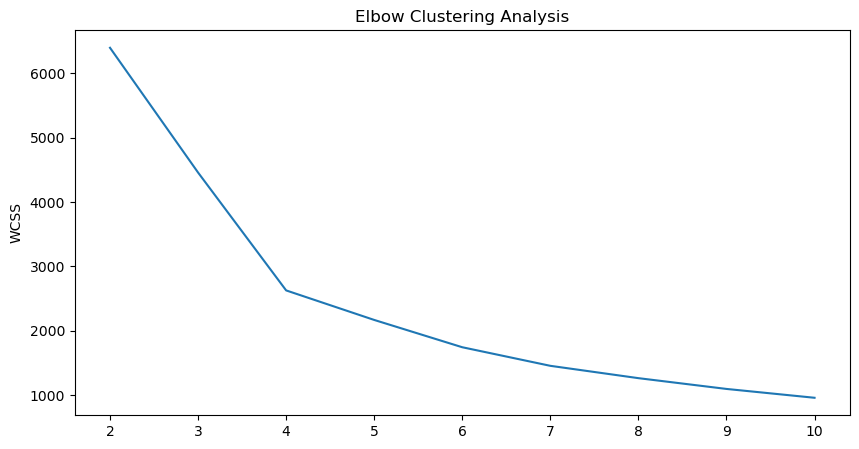

In [8]:
# Define a list for housing Within-Cluster Sum of Squares (WCSS) scores
wcss = pd.DataFrame()

for i in range(2,11):
    # Define the K-Means model
    kmeans_elbow = KMeans(n_clusters = i,
                          random_state = random_seed_num)

    # Fit the scaled data
    kmeans_elbow.fit(data_scaled)

    # Add WCSS score to wcss list
    wcss.loc[i,'WCSS'] = kmeans_elbow.inertia_

# Plot the WCSS scores to find the elbow
fig, ax = plt.subplots(figsize = (10, 5))
sns.lineplot(wcss,
             x = wcss.index,
             y = 'WCSS',
             ax = ax)
plt.title('Elbow Clustering Analysis')
plt.show()

According to the plot above, there is a significant decrease of the WCSS score between 3 and 4 clusters, however, the improvement of the score levels off after that creating an "elbow" shape in the curve. Therefore 4 clusters appears to be the ideal number of clusters for this data.

## Parameter Tuning: Silhouette Method

Another method used to determine the ideal number of clusters in a model, often used in conjunction with the elbow method, is call the silhouette method. The silhouette method is measure by a score ranging from -1 to 1 where the higher the score, the better the clustering. Overall, the silhouette score measure how separate clusters are from each other in a model.

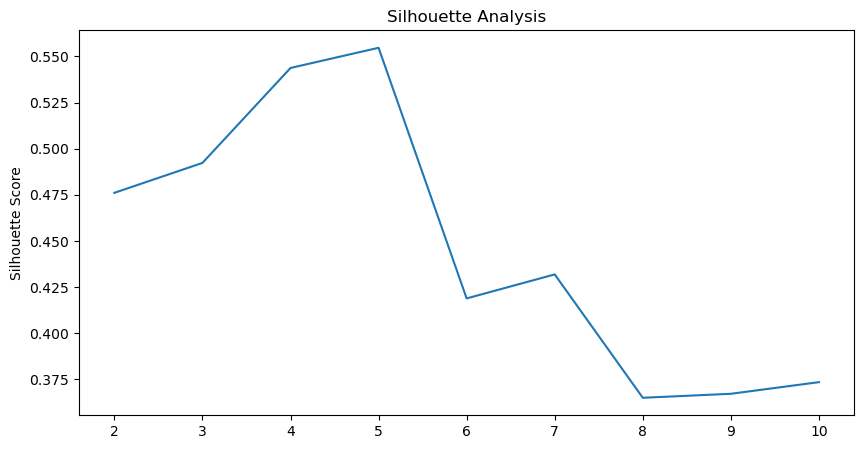

In [9]:
# Define a list for housing silhouette scores
silhouette_scores = pd.DataFrame()

for i in range(2,11):
    # Define the K-Means model
    kmeans_silho = KMeans(n_clusters = i,
                          random_state = random_seed_num)

    # Fit the scaled data
    cluster_labels = kmeans_silho.fit_predict(data_scaled)

    # Add WCSS score to wcss list
    silhouette_scores.loc[i,'Silhouette Score'] = silhouette_score(data_scaled,
                                                                   cluster_labels)

# Plot the WCSS scores to find the elbow
fig, ax = plt.subplots(figsize = (10, 5))
sns.lineplot(silhouette_scores,
             x = silhouette_scores.index,
             y = 'Silhouette Score',
             ax = ax)
plt.title('Silhouette Analysis')
plt.show()

Similar to the elbow analysis, the optimal number of clusters for this data appears to be 4 or 5 given there is a drop off after 5 clusters. By going with 4 clusters, we decrease the risk of over-fitting the data.

## Final Modeling

Now that we've decided on the number of clusters that best describes this data, the next step would be to defining a finalized model.

In [10]:
kmean_final = KMeans(n_clusters = 4,
                     random_state = random_seed_num)

In [11]:
kmean_predict = kmean_final.fit_predict(data_scaled)

In [12]:
data_features['Cluster Label'] = kmean_predict

In [13]:
data_features.head(5)

,TotalSpend,day_since_last_purchase,AvgDaysBetweenPurchases,Cluster Label
1,4310.00,24,60.333333,0
2,1797.24,97,94.000000,0
5,2506.04,58,36.857143,0
9,2811.43,44,151.000000,2
11,1168.06,23,149.000000,2


# Cluster Analysis

In [16]:
# Descriptive analytical summary
data_features.groupby('Cluster Label').describe().transpose()

Cluster Label                             0             1            2  \
TotalSpend              count   1991.000000    442.000000   404.000000   
                        mean    3057.343707   1136.642740   790.318814   
                        std     5854.361418   2964.464938   805.019784   
                        min        6.900000     52.000000    52.200000   
                        25%      836.195000    383.915000   379.650000   
                        50%     1592.060000    638.945000   602.940000   
                        75%     3052.905000   1108.087500   883.397500   
                        max    81024.840000  44534.300000  7829.890000   
day_since_last_purchase count   1991.000000    442.000000   404.000000   
                        mean      51.150678    219.647059    74.069307   
                        std       27.396996     61.463536    39.987469   
                        min       22.000000    135.000000    23.000000   
                        25%       30.000000    172.250000    41.000000   
                        50%       43.000000    208.500000    66.500000   
                        75%       65.000000    258.000000    96.000000   
                        max      136.000000    395.000000   209.000000   
AvgDaysBetweenPurchases count   1991.000000    442.000000   404.000000   
                        mean      50.023012     54.248724   202.657178   
                        std       29.816780     39.392360    65.182465   
                        min        0.000000      0.000000   120.000000   
                        25%       26.450000     23.093750   153.000000   
                        50%       45.285714     47.666667   182.500000   
                        75%       69.600000     80.875000   243.250000   
                        max      129.000000    164.000000   365.000000   

Cluster Label                              3  
TotalSpend              count       8.000000  
                        mean   172508.526250  
                        std     68092.803775  
                        min     91062.380000  
                        25%    123030.805000  
                        50%    156148.780000  
                        75%    210827.417500  
                        max    280206.020000  
day_since_last_purchase count       8.000000  
                        mean       27.625000  
                        std         8.227784  
                        min        22.000000  
                        25%        22.750000  
                        50%        23.500000  
                        75%        30.250000  
                        max        46.000000  
AvgDaysBetweenPurchases count       8.000000  
                        mean       32.263590  
                        std        69.530044  
                        min         1.470000  
                        25%         5.952184  
                        50%         7.133333  
                        75%        12.599745  
                        max       204.000000

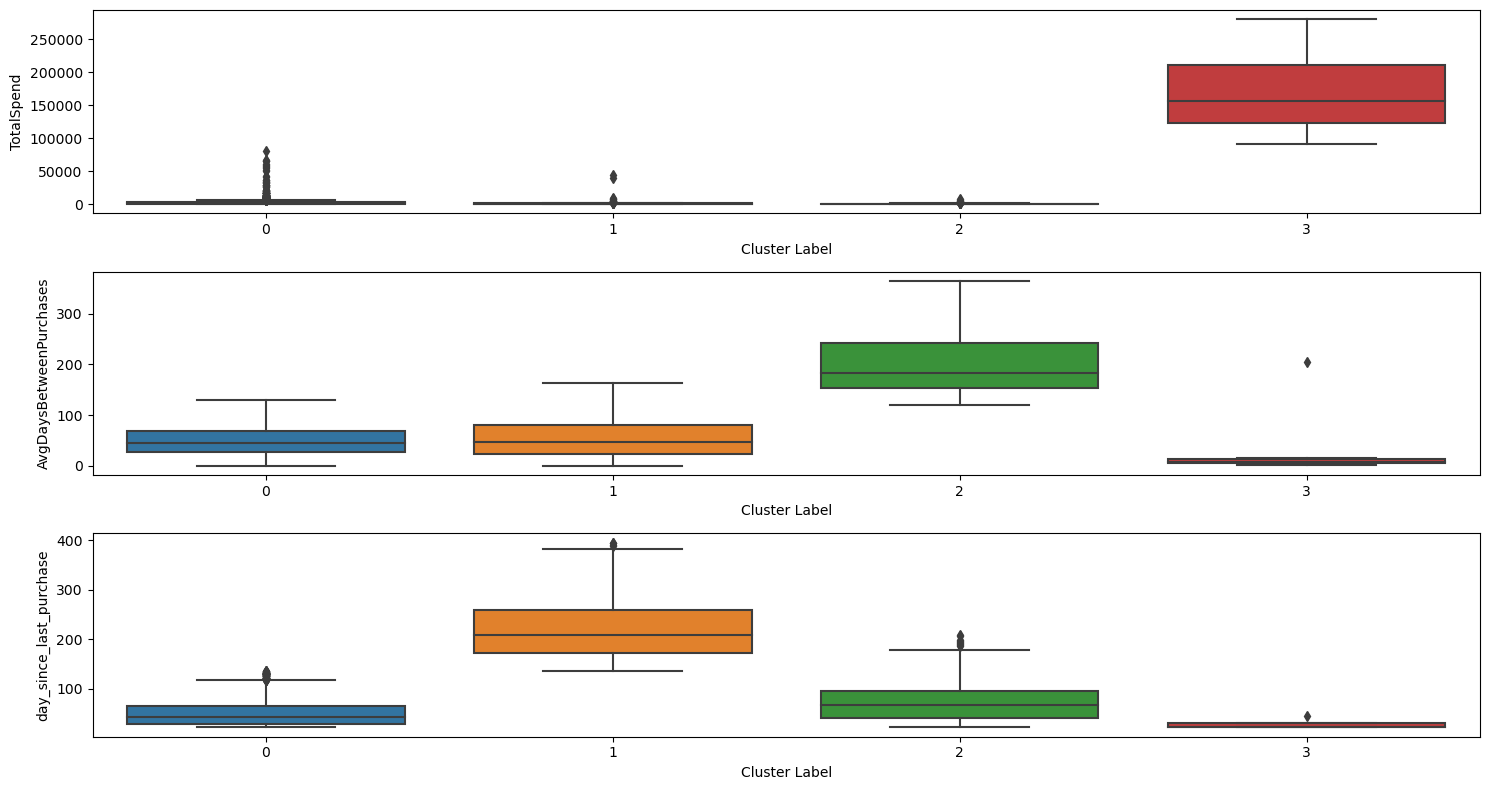

In [14]:
# Plot distibution of features by cluster label
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 3,
                                    ncols = 1,
                                    figsize = (15,8))

sns.boxplot(data_features,
            x = 'Cluster Label',
            y = 'TotalSpend',
            ax = ax1)

sns.boxplot(data_features,
            x = 'Cluster Label',
            y = 'AvgDaysBetweenPurchases',
            ax = ax2)

sns.boxplot(data_features,
            x = 'Cluster Label',
            y = 'day_since_last_purchase',
            ax = ax3)


plt.tight_layout()
plt.show()

By looking at the three box plots above, we can start to see the different characteristics between each cluster. The most obvious one is `Cluster 3`, with overall greater spending and shorter time between purchases than the other clusters. `Cluster 0` also appear to be repeat customers but don't tend to spend as much as `Cluster 3`. `Cluster 2` appear to be low spending customers who have churned but have returned. `Cluster 1` looks to represent the other side of that coin of low spending customers who have churned and not returned. 
To recap:
- `Cluster 3`: Loyal high spending customers
- `Cluster 0`: Loyal lower spending customers
- `Cluster 2`: Returning churned customers
- `Cluster 1`: One-time customers